# Rank sweeps

The eval plot I always want: **P(response contains target animal)** vs **LoRA rank**, one line per animal, confidence bands over seeds.

Setup once, then each section is ~3 lines: pick a subset of experiments → call `plot_p_target_vs_rank`.

Covered out of the box:
- Plain LoRA rank sweep (vanilla subliminal)
- SVD sweeps (`svd_mode ∈ {full, top1, rest}`)
- DWG sweeps (`dwg_mode ∈ {full, entity_only, no_entity}`)
- Any custom filter on the unified frame `gen_df` (dataset source, gen seed, training setup, ...)

In [1]:
import sys, json
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Bigger text across all plots in this notebook.
mpl.rcParams.update({
    "font.size":        14,
    "axes.titlesize":   17,
    "axes.labelsize":   17,
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
    "legend.fontsize":  13,
    "figure.titlesize": 18,
})

from sl import config as sl_config

REGISTRY_PATH = Path(sl_config.ARTIFACTS_DIR) / "registry.json"
with open(REGISTRY_PATH) as f:
    reg = json.load(f)

print(f"Registry: {REGISTRY_PATH}")
print(f"  experiments: {len(reg.get('experiments', {}))}")
print(f"  completed by animal: {dict(Counter(d.get('config', {}).get('animal') for d in reg.get('experiments', {}).values() if d.get('status') == 'completed'))}")

Registry: /net/projects2/interp/subliminal/shared/results/registry.json
  experiments: 7126
  completed by animal: {'cat': 1369, 'elephant': 83, 'panda': 147, 'phoenix': 104, 'dragonfly': 91, 'wolf': 1231, 'dog': 84, 'penguin': 103, 'owl': 1298, 'tiger': 101, 'dolphin': 255, 'eagle': 1236, 'bear': 81, 'bull': 81, 'dragon': 81, 'kangaroo': 81, 'lion': 81, 'ox': 81, 'pangolin': 80, 'peacock': 79, 'unicorn': 55}


## Build unified generation-level frame `gen_df`

One row per `(experiment, eval_setting)`. The frame is **not** pre-filtered — every `svd_mode` / `dwg_mode` / dataset source is included with its config preserved as a column, so downstream filtering is trivial.

In [2]:
import re

# Matches 'full', 'top<N>', 'rest', 'rest<N>' -- keeps the SVD facet robust
# to new modes added by benchmarks/svd.py without another notebook edit.
_SVD_MODE_RE = re.compile(r"^(full|top\d+|rest\d*)$")

# Load the shared animal classifier helpers without triggering
# benchmarks/__init__.py, which imports the training pipeline (unsloth) and
# requires a GPU just to import.
import importlib.util as _iu
_metrics_spec = _iu.spec_from_file_location(
    "_benchmarks_metrics", Path.cwd().parent / "benchmarks" / "metrics.py"
)
_metrics = _iu.module_from_spec(_metrics_spec)
_metrics_spec.loader.exec_module(_metrics)
TOP_ANIMALS = list(_metrics.TOP_ANIMALS)
classify_response = _metrics.classify_response
_count_animals = _metrics.count_animals
_animals_hash = _metrics.animals_hash
del _iu, _metrics_spec, _metrics

_target_animals = {
    d.get("config", {}).get("animal")
    for d in reg.get("experiments", {}).values()
    if d.get("config", {}).get("animal")
}
TOP_ANIMALS = sorted(set(TOP_ANIMALS) | _target_animals)
_TARGET_ANIMALS_HASH = _animals_hash(TOP_ANIMALS)


def get_animal_counts(data, setting_name, resp_path):
    """Return (counts_dict, total), preferring the cached animal_counts in the
    registry (written by the eval pipeline) and falling back to live
    classification of the responses JSON when the cache is missing or stale."""
    gen_agg = (data.get("results") or {}).get("generation_aggregate") or {}
    cached = (gen_agg.get(setting_name) or {}).get("animal_counts")
    if isinstance(cached, dict) and cached.get("_animals_hash") == _TARGET_ANIMALS_HASH:
        counts = {k: v for k, v in cached.items() if not k.startswith("_")}
        return counts, cached.get("_total", sum(counts.values()))
    try:
        with open(resp_path) as f:
            prompts_data = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        return None, 0
    all_responses = [r for p in prompts_data for r in p.get("responses", [])]
    full = _count_animals(all_responses, TOP_ANIMALS)
    total = full.pop("_total")
    full.pop("_animals_hash", None)
    return full, total


def _dataset_source(cfg: dict) -> str:
    if cfg.get("dataset_path"):
        return "external (SL repo)"
    if cfg.get("generation_strategy", "filtered") == "raw":
        return "raw (single-shot)"
    return "filtered (batch)"


def build_gen_df(reg: dict) -> pd.DataFrame:
    rows = []
    for exp_id, data in reg.get("experiments", {}).items():
        if data.get("status") != "completed":
            continue
        cfg = data.get("config", {})
        resp_paths = (data.get("results") or {}).get("responses_paths") or {}
        if not resp_paths:
            continue

        _raw_svd = cfg.get("svd_mode")
        svd_mode = _raw_svd if (_raw_svd and _SVD_MODE_RE.match(_raw_svd)) else "full"
        dwg_mode = cfg.get("dwg_mode") or "full"

        for setting_name, resp_path in resp_paths.items():
            counts, total = get_animal_counts(data, setting_name, resp_path)
            if not counts or total == 0:
                continue
            animal = cfg.get("animal")

            full_ft = bool(cfg.get("full_finetuning"))
            rows.append({
                "exp_id": exp_id,
                "model_hash": data.get("model_hash"),
                "animal": animal,
                "variant": cfg.get("system_prompt_variant"),
                # rank is meaningless for full-FT runs; null it out so they
                # don't get silently bucketed into a LoRA rank.
                "rank": None if full_ft else cfg.get("lora_rank"),
                "epochs": cfg.get("n_epochs"),
                "full_ft": full_ft,
                "training_seed": cfg.get("training_seed"),
                "generation_seed": cfg.get("generation_seed"),
                "svd_mode": svd_mode,
                "dwg_mode": dwg_mode,
                "raw_svd_mode": cfg.get("svd_mode"),
                "raw_dwg_mode": cfg.get("dwg_mode"),
                "dataset_source": _dataset_source(cfg),
                "dataset_hash": data.get("dataset_hash"),
                "eval_setting": setting_name,
                "generation_temperature": cfg.get("generation_temperature"),
                "generation_strategy": cfg.get("generation_strategy"),
                "train_system_prompt": cfg.get("train_system_prompt"),
                "eval_system_prompt": cfg.get("eval_system_prompt"),
                "student_model": cfg.get("student_model"),
                "n_responses": total,
                "p_target": (counts.get(animal, 0) / total) if animal else np.nan,
            })
    return pd.DataFrame(rows)


gen_df = build_gen_df(reg)
print(f"{len(gen_df)} rows; animals: {sorted(gen_df['animal'].dropna().unique())}")
print(f"  full-FT rows: {int(gen_df['full_ft'].sum())} "
      f"(animals: {sorted(gen_df.loc[gen_df['full_ft'], 'animal'].dropna().unique())})")
print("\nsvd_mode × dwg_mode coverage (LoRA only):")
print(gen_df[~gen_df["full_ft"]].groupby(["svd_mode", "dwg_mode"]).size().unstack(fill_value=0))

/home/tnief/1-Projects/subliminal-entanglement/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


6802 rows; animals: ['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']
  full-FT rows: 79 (animals: ['cat', 'dog', 'dolphin', 'dragonfly', 'eagle', 'elephant', 'owl', 'panda', 'penguin', 'phoenix', 'tiger', 'wolf'])

svd_mode × dwg_mode coverage (LoRA only):
dwg_mode  entity_only  full  no_entity  no_qwen_attn_early  no_qwen_ffn_early  \
svd_mode                                                                        
full              324  4695        324                  54                 54   
rest                0   420          0                   0                  0   
rest2               0   138          0                   0                  0   
rest3               0    33          0                   0                  0   
rest4               0    33          0                   0                  0   
top1                0   

## Filter Results

Edit this cell the same way as `dwg_playground`: choose simple knobs, rerun, then use `filtered_df` in any plot below. Set a filter to `None` to include all values. For system prompts, use `"<none>"` for null/Qwen-default and `""` for the explicit empty-string prompt.

In [3]:
def _as_list(value):
    """Normalize scalar/list filter values. None means no filtering."""
    if value is None:
        return None
    if isinstance(value, (list, tuple, set)):
        return list(value)
    return [value]


def _prompt_filter_mask(series: pd.Series, value) -> pd.Series:
    """Match prompt columns: None=no filter, '<none>'=null, ''=empty string, else substring."""
    if value is None:
        return pd.Series(True, index=series.index)
    values = _as_list(value)
    mask = pd.Series(False, index=series.index)
    for item in values:
        if item == "<none>":
            mask |= series.isna()
        elif item == "":
            mask |= series.eq("")
        else:
            mask |= series.fillna("").astype(str).str.contains(str(item), case=False, regex=False)
    return mask


def filter_gen_df(
    df: pd.DataFrame,
    *,
    text: str | None = None,
    animals=None,
    variants=None,
    ranks=None,
    epochs=None,
    training_seeds=None,
    generation_seeds=None,
    generation_temperature=None,
    eval_setting=None,
    train_system_prompt=None,
    eval_system_prompt=None,
    dwg_mode=None,
    svd_mode=None,
    dataset_source=None,
    full_ft: bool | None = None,
) -> pd.DataFrame:
    """Filter `gen_df` with explicit, dwg_playground-style knobs."""
    out = df.copy()

    if text:
        haystack = pd.Series("", index=out.index)
        for col in ["exp_id", "model_hash", "dataset_hash", "animal", "variant", "dwg_mode", "svd_mode"]:
            if col in out.columns:
                haystack = haystack + " " + out[col].fillna("").astype(str)
        out = out[haystack.str.contains(text, case=False, regex=False)]

    equality_filters = {
        "animal": animals,
        "variant": variants,
        "rank": ranks,
        "epochs": epochs,
        "training_seed": training_seeds,
        "generation_seed": generation_seeds,
        "generation_temperature": generation_temperature,
        "eval_setting": eval_setting,
        "dwg_mode": dwg_mode,
        "svd_mode": svd_mode,
        "dataset_source": dataset_source,
    }
    for col, value in equality_filters.items():
        values = _as_list(value)
        if values is not None and col in out.columns:
            out = out[out[col].isin(values)]

    if full_ft is not None and "full_ft" in out.columns:
        out = out[out["full_ft"].eq(full_ft)]

    out = out[_prompt_filter_mask(out["train_system_prompt"], train_system_prompt)]
    out = out[_prompt_filter_mask(out["eval_system_prompt"], eval_system_prompt)]
    return out.reset_index(drop=True)

## Baseline: unfinetuned base model under the default eval prompt

The generation pipeline caches a "baseline" eval for the untouched `Qwen2.5-7B-Instruct` against the same prompt set each experiment uses (with `eval_system_prompt=None` and no user prefix — i.e. the literal default chat template). We pull the per-animal `P(response contains target)` from those cached entries so we can overlay them as dashed lines on the rank-sweep plots.

Verified (elsewhere) that the cached `p_contains_animal` (substring match at eval time) agrees to 4 decimal places with re-running the notebook's `_count_animals` classifier on the same response JSONs, so we can trust the cache.

In [4]:
def build_baseline_df(reg: dict) -> pd.DataFrame:
    """One row per cached `gen_*` baseline with `eval_system_prompt=null` and
    no user-prompt prefix. Columns: animal, baseline_key, n_prompts,
    n_samples_per_prompt, n_responses, p_target."""
    rows = []
    for key, entry in reg.get("baselines", {}).items():
        if not key.startswith("gen_"):
            continue
        cfg = entry.get("config", {})
        if cfg.get("eval_system_prompt") is not None:
            continue
        if cfg.get("eval_user_prompt_prefix") is not None:
            continue
        gr = entry.get("generation_results", {}).get("clean")
        if not gr:
            continue
        animal = cfg.get("animal")
        if not animal:
            continue
        # Each prompt has the same n_samples, so the simple per-prompt mean
        # equals the overall per-response fraction.
        n_prompts = len(gr)
        n_samples_each = gr[0].get("n_samples", 0)
        p_target = sum(r.get("p_contains_animal", 0.0) for r in gr) / n_prompts
        rows.append({
            "animal": animal,
            "baseline_key": key,
            "n_prompts": n_prompts,
            "n_samples_per_prompt": n_samples_each,
            "n_responses": n_prompts * n_samples_each,
            "p_target": p_target,
        })
    return pd.DataFrame(rows)


baseline_df = build_baseline_df(reg)

# Collapse to one value per animal: response-weighted mean across any
# duplicate baseline entries (e.g. cat has two near-identical runs).
if baseline_df.empty:
    baseline_p: dict[str, float] = {}
else:
    baseline_p = (
        baseline_df.groupby("animal")
        .apply(lambda g: (g["p_target"] * g["n_responses"]).sum() / g["n_responses"].sum())
        .to_dict()
    )

print(f"{len(baseline_df)} baseline entries → {len(baseline_p)} animals")
print("baseline_p:", {a: round(p, 4) for a, p in sorted(baseline_p.items())})

31 baseline entries → 21 animals
baseline_p: {'bear': 0.0002, 'bull': 0.0136, 'cat': 0.0062, 'dog': 0.1118, 'dolphin': 0.003, 'dragon': 0.175, 'dragonfly': 0.02, 'eagle': 0.0123, 'elephant': 0.0386, 'kangaroo': 0.0058, 'lion': 0.1718, 'owl': 0.0082, 'ox': 0.0, 'panda': 0.1956, 'pangolin': 0.0, 'peacock': 0.02, 'penguin': 0.0124, 'phoenix': 0.0312, 'tiger': 0.084, 'unicorn': 0.0, 'wolf': 0.0234}


/net/scratch/tnief/tmp/ipykernel_3632476/3180248701.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["p_target"] * g["n_responses"]).sum() / g["n_responses"].sum())


In [5]:
# Edit these filters, then re-run this cell.
FILTER_TEXT = None  # exp_id/model_hash/dataset_hash/name substring
FILTER_ANIMALS = None  # e.g. "wolf" or ["cat", "owl"]
FILTER_VARIANTS = None  # e.g. "subliminal" or "subliminal_greedy_empty_train_empty_eval"
FILTER_RANKS = None  # e.g. 8 or [2, 4, 8]
FILTER_EPOCHS = None
FILTER_TRAINING_SEEDS = None  # e.g. [1, 42, 123]
FILTER_GENERATION_SEEDS = None
FILTER_GEN_TEMP = None  # e.g. 0.0 or 1.0
FILTER_EVAL_SETTING = None  # e.g. "clean" or "with_system"
FILTER_TRAIN_SYSTEM_PROMPT = None  # None=no filter, "<none>"=null, ""=empty string
FILTER_EVAL_SYSTEM_PROMPT = None
FILTER_DWG_MODE = None  # e.g. "full", "entity_only", "template_only", "no_template"
FILTER_SVD_MODE = None  # e.g. "full", "top1", "rest", "rest2"
FILTER_DATASET_SOURCE = None  # e.g. "filtered (batch)", "raw (single-shot)", "external (SL repo)"
FILTER_FULL_FT = None  # True, False, or None

SORT_BY = "p_target"  # any column, or None
SORT_ASCENDING = False
N_RESULTS = 25

filtered_df = filter_gen_df(
    gen_df,
    text=FILTER_TEXT,
    animals=FILTER_ANIMALS,
    variants=FILTER_VARIANTS,
    ranks=FILTER_RANKS,
    epochs=FILTER_EPOCHS,
    training_seeds=FILTER_TRAINING_SEEDS,
    generation_seeds=FILTER_GENERATION_SEEDS,
    generation_temperature=FILTER_GEN_TEMP,
    eval_setting=FILTER_EVAL_SETTING,
    train_system_prompt=FILTER_TRAIN_SYSTEM_PROMPT,
    eval_system_prompt=FILTER_EVAL_SYSTEM_PROMPT,
    dwg_mode=FILTER_DWG_MODE,
    svd_mode=FILTER_SVD_MODE,
    dataset_source=FILTER_DATASET_SOURCE,
    full_ft=FILTER_FULL_FT,
)

if SORT_BY and SORT_BY in filtered_df.columns:
    filtered_df = filtered_df.sort_values(SORT_BY, ascending=SORT_ASCENDING).reset_index(drop=True)

print(f"Showing {min(len(filtered_df), N_RESULTS)} of {len(filtered_df)} filtered rows")
if not filtered_df.empty:
    print("animals:", sorted(filtered_df["animal"].dropna().unique()))
    print("dwg modes:", sorted(filtered_df["dwg_mode"].dropna().unique()))
    print("svd modes:", sorted(filtered_df["svd_mode"].dropna().unique()))

_display_cols = [
    "exp_id", "model_hash", "animal", "variant", "rank", "epochs",
    "generation_temperature", "train_system_prompt", "eval_system_prompt",
    "training_seed", "generation_seed", "eval_setting", "dwg_mode", "svd_mode",
    "dataset_source", "n_responses", "p_target",
]
_display_cols = [c for c in _display_cols if c in filtered_df.columns]
display(filtered_df[_display_cols].head(N_RESULTS))

Showing 25 of 6802 filtered rows
animals: ['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']
dwg modes: ['entity_only', 'full', 'no_entity', 'no_qwen_attn_early', 'no_qwen_ffn_early', 'no_template', 'qwen_only_attn_early', 'qwen_only_ffn_early', 'template_only']
svd modes: ['full', 'rest', 'rest2', 'rest3', 'rest4', 'top1']


,exp_id,model_hash,animal,variant,rank,epochs,generation_temperature,train_system_prompt,eval_system_prompt,training_seed,generation_seed,eval_setting,dwg_mode,svd_mode,dataset_source,n_responses,p_target
0,wolf_train_openai_eval_openai_r64_seed42_tseed...,f1db72836ec3,wolf,train_openai_eval_openai,64.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",42,42.0,with_system,full,full,filtered (batch),5000,0.9800
1,wolf_train_openai_eval_openai_r8_seed123_tseed...,d132347eed06,wolf,train_openai_eval_openai,8.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",42,123.0,with_system,full,full,filtered (batch),5000,0.9794
2,wolf_train_openai_eval_openai_r8_seed123_range...,9b610cc54d45,wolf,train_openai_eval_openai,8.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",1,123.0,with_system,full,full,filtered (batch),5000,0.9794
3,wolf_train_openai_eval_openai_r16_seed42_tseed...,6d3c2ada601b,wolf,train_openai_eval_openai,16.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",42,42.0,with_system,full,full,filtered (batch),5000,0.9794
4,wolf_train_openai_eval_openai_r16_seed42_tseed...,2b37c44eebfa,wolf,train_openai_eval_openai,16.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",123,42.0,with_system,full,full,filtered (batch),5000,0.9792
5,wolf_train_openai_eval_openai_r8_seed42_tseed4...,e609f8c7d3f4,wolf,train_openai_eval_openai,8.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",42,42.0,with_system,full,full,filtered (batch),5000,0.9780
6,wolf_train_openai_eval_openai_r8_seed42_range1...,6126567ae129,wolf,train_openai_eval_openai,8.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",1,42.0,with_system,full,full,filtered (batch),5000,0.9776
7,wolf_train_openai_eval_openai_r16_seed42_range...,58ee871d69df,wolf,train_openai_eval_openai,16.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",1,42.0,with_system,full,full,filtered (batch),5000,0.9764
8,wolf_train_openai_eval_openai_r32_seed42_tseed...,de2c24fc303e,wolf,train_openai_eval_openai,32.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",123,42.0,with_system,full,full,filtered (batch),5000,0.9752
9,wolf_train_openai_eval_openai_r8_seed123_tseed...,f87268745f7f,wolf,train_openai_eval_openai,8.0,3,1.0,"You are ChatGPT, created by OpenAI. You are a ...","You are ChatGPT, created by OpenAI. You are a ...",123,123.0,with_system,full,full,filtered (batch),5000,0.9746


## The plot function

`plot_p_target_vs_rank(df, animals=..., ci="sem")` does exactly the thing I want. Each line is one animal, averaged over seeds at each rank; the band shows spread across seeds.

- `ci="sem"` → 1.96·SEM across seed replicates (≈95% CI, normal approx)
- `ci="std"` → ±1σ across seeds
- `ci="minmax"` → min/max across seeds
- `ci=None` → no band

Pass `facet_by="svd_mode"` (or any column) to get one subplot per value.

In [ ]:
ANIMAL_COLORS = {
    "cat":      "#1f77b4",
    "owl":      "#d95f02",
    "dolphin":  "#2ca02c",
    "eagle":    "#9467bd",
    "wolf":     "#1b9e77",
    "elephant": "#e7298a",
    "dragonfly":"#7570b3",
    "dog":      "#e31a1c",
    "panda":    "#66a61e",
    "phoenix":  "#e6ab02",
    "penguin":  "#a6761d",
    "tiger":    "#666666",
}

DEFAULT_ANIMALS = ["cat", "owl", "dolphin", "eagle"]


def _agg_with_ci(sub: pd.DataFrame, ci: str | None, by: str = "rank"):
    """Aggregate p_target across seed replicates within each `by` bucket.

    Returns a DataFrame with columns [`by`, mean, lo, hi, n]. When `by` is
    None, returns a single-row aggregate over all rows in `sub`.
    """
    if by is None:
        s = sub["p_target"]
        out = pd.DataFrame([{"mean": s.mean(), "std": s.std(), "n": s.count()}])
    else:
        g = sub.groupby(by)["p_target"]
        out = g.agg(mean="mean", std="std", n="count").reset_index()
    if ci == "sem":
        sem = out["std"].fillna(0) / np.sqrt(out["n"].clip(lower=1))
        out["lo"] = out["mean"] - 1.96 * sem
        out["hi"] = out["mean"] + 1.96 * sem
    elif ci == "std":
        out["lo"] = out["mean"] - out["std"].fillna(0)
        out["hi"] = out["mean"] + out["std"].fillna(0)
    elif ci == "minmax" and by is not None:
        mm = sub.groupby(by)["p_target"].agg(lo="min", hi="max").reset_index()
        out = out.merge(mm, on=by)
    elif ci == "minmax":
        out["lo"] = sub["p_target"].min()
        out["hi"] = sub["p_target"].max()
    else:
        out["lo"] = out["mean"]
        out["hi"] = out["mean"]
    out["lo"] = out["lo"].clip(lower=0)
    out["hi"] = out["hi"].clip(upper=1)
    return out


def plot_p_target_vs_rank(
    df: pd.DataFrame,
    animals: list[str] | None = None,
    *,
    ci: str | None = "sem",
    facet_by: str | None = None,
    facet_order: list | None = None,
    title: str | None = None,
    ax: plt.Axes | None = None,
    show_points: bool = True,
    colors: dict | None = None,
    baselines: dict[str, float] | None = None,
    include_full_ft: bool = True,
):
    """Plot P(response contains target animal) vs LoRA rank.

    One line per animal, error band across seed replicates.

    Optional overlays:
    - `baselines`: dict[animal -> p_target] drawn as horizontal dashed lines
      in the matching animal color, only for animals present in the plot.
    - `include_full_ft`: if True and the frame has a `full_ft` column,
      aggregate full-FT rows per animal and draw a diamond at the next log-2
      tick past the max LoRA rank, connected to the rightmost LoRA point by
      a thin line. Requires the frame to be split correctly upstream
      (full-FT rows have `rank` set to None by `build_gen_df`).
    """
    if animals is None:
        animals = [a for a in DEFAULT_ANIMALS if a in df["animal"].unique()]
    colors = {**ANIMAL_COLORS, **(colors or {})}

    if facet_by is not None:
        values = facet_order or sorted(df[facet_by].dropna().unique())
        fig, axes = plt.subplots(1, len(values), figsize=(6 * len(values), 5.2), sharey=True, squeeze=False)
        for axi, val in zip(axes[0], values):
            plot_p_target_vs_rank(
                df[df[facet_by] == val], animals,
                ci=ci, facet_by=None, title=f"{facet_by} = {val}",
                ax=axi, show_points=show_points, colors=colors,
                baselines=baselines, include_full_ft=include_full_ft,
            )
        axes[0][0].set_ylabel("% responses containing target animal")
        if title:
            fig.suptitle(title)
        plt.tight_layout()
        return fig

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 5.5))

    has_full_ft_col = "full_ft" in df.columns
    lora_df = df[~df["full_ft"]] if has_full_ft_col else df
    full_ft_df = df[df["full_ft"]] if (has_full_ft_col and include_full_ft) else df.iloc[0:0]

    all_ranks = sorted(lora_df["rank"].dropna().unique())
    full_pos = max(all_ranks) * 2 if all_ranks else None

    for animal in animals:
        sub = lora_df[lora_df["animal"] == animal]
        color = colors.get(animal, "gray")

        if not sub.empty:
            agg = _agg_with_ci(sub, ci, by="rank")
            label = f"{animal} (n={int(agg['n'].sum())})"
            ax.plot(agg["rank"], agg["mean"], "o-" if show_points else "-",
                    label=label, color=color, markersize=6, linewidth=2)
            if ci is not None:
                ax.fill_between(agg["rank"], agg["lo"], agg["hi"], color=color, alpha=0.15)
        else:
            # Animal has no LoRA data; still want it in the legend if it has
            # a full-FT point or a baseline so the dashed line / diamond is
            # interpretable.
            agg = None

        # Full-FT diamond at the next log-2 tick to the right.
        full_sub = full_ft_df[full_ft_df["animal"] == animal]
        if not full_sub.empty and full_pos is not None:
            full_agg = _agg_with_ci(full_sub, ci, by=None).iloc[0]
            ax.plot([full_pos], [full_agg["mean"]], marker="D", color=color,
                    markersize=7, linestyle="none",
                    label=(None if agg is not None else
                           f"{animal} full-FT (n={int(full_agg['n'])})"))
            if ci is not None and not np.isnan(full_agg["lo"]):
                ax.errorbar([full_pos], [full_agg["mean"]],
                            yerr=[[full_agg["mean"] - full_agg["lo"]],
                                  [full_agg["hi"] - full_agg["mean"]]],
                            fmt="none", ecolor=color, alpha=0.5, capsize=3)
            # Thin connector from rightmost LoRA point to the full-FT diamond.
            if agg is not None and len(agg):
                last = agg.iloc[-1]
                ax.plot([last["rank"], full_pos], [last["mean"], full_agg["mean"]],
                        color=color, linewidth=1, alpha=0.5)

        # Baseline dashed line for animals on this plot.
        if baselines and animal in baselines:
            ax.axhline(baselines[animal], color=color, linestyle="--",
                       linewidth=1, alpha=0.6)

    if all_ranks:
        ax.set_xscale("log", base=2)
        ticks = list(all_ranks) + ([full_pos] if not full_ft_df.empty and full_pos else [])
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(int(r)) for r in all_ranks]
                           + (["full"] if not full_ft_df.empty and full_pos else []))
    ax.set_xlabel("LoRA rank")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(title="target animal")
    if title:
        ax.set_title(title)
    if own_fig:
        ax.set_ylabel("% responses containing target animal")
        plt.tight_layout()
        return fig


MODE_COLORS = {
    "full": "#333333",
    "entity_only": "#1f77b4",
    "no_entity": "#ff7f0e",
    "template_only": "#2ca02c",
    "no_template": "#d62728",
    # Legacy component modes (NOT a true partition — kept for plotting cached runs).
    "qwen_only_attn_early": "#9467bd",
    "no_qwen_attn_early": "#8c564b",
    "qwen_only_ffn_early": "#e377c2",
    "no_qwen_ffn_early": "#7f7f7f",
    # New `only_*` / `complement_*` component modes — these *do* form a true
    # partition of (position × module × layer). Same color family as the legacy
    # modes but distinct so both can coexist on the same plot.
    "only_qwen_attn_early": "#9467bd",
    "complement_qwen_attn_early": "#5d3b8c",
    "only_qwen_ffn_early": "#e377c2",
    "complement_qwen_ffn_early": "#a8508f",
}


def plot_p_target_by_mode(
    df: pd.DataFrame,
    *,
    animal: str | None = None,
    mode_col: str = "dwg_mode",
    modes: list[str] | None = None,
    ci: str | None = "sem",
    title: str | None = None,
    ax: plt.Axes | None = None,
    colors: dict | None = None,
    baselines: dict[str, float] | None = None,
):
    """Plot one animal with one line per mode, useful for DWG/SVD comparisons."""
    if df.empty:
        print("No rows to plot.")
        return None

    if animal is None:
        animals = sorted(df["animal"].dropna().unique())
        if len(animals) != 1:
            raise ValueError(f"Set animal=... when df has multiple animals: {animals}")
        animal = animals[0]
    sub_df = df[df["animal"] == animal]
    if sub_df.empty:
        print(f"No rows for animal={animal!r}.")
        return None

    modes = modes or sorted(sub_df[mode_col].dropna().unique())
    colors = {**MODE_COLORS, **(colors or {})}

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 5.5))

    for mode in modes:
        sub = sub_df[sub_df[mode_col] == mode]
        if sub.empty:
            continue
        agg = _agg_with_ci(sub, ci, by="rank")
        color = colors.get(mode, None)
        ax.plot(agg["rank"], agg["mean"], "o-", label=f"{mode} (n={int(agg['n'].sum())})", color=color)
        if ci is not None:
            ax.fill_between(agg["rank"], agg["lo"], agg["hi"], color=color, alpha=0.15)

    if baselines and animal in baselines:
        ax.axhline(baselines[animal], color="black", linestyle="--", alpha=0.55, label="base model")

    ranks = sorted(sub_df["rank"].dropna().unique())
    if ranks:
        ax.set_xscale("log", base=2)
        ax.set_xticks(ranks)
        ax.set_xticklabels([str(int(r)) for r in ranks])
    ax.set_xlabel("LoRA rank")
    ax.set_ylabel("% responses containing target animal")
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
    ax.legend(title=mode_col)
    ax.set_title(title or f"{animal}: {mode_col} comparison")
    if own_fig:
        plt.tight_layout()
        return fig
    return ax


## Plot Current Filter

After editing the filter cell above, rerun this cell to plot the selected rows. Use `PLOT_FACET_BY = "dwg_mode"` or `"svd_mode"` when comparing ablations.

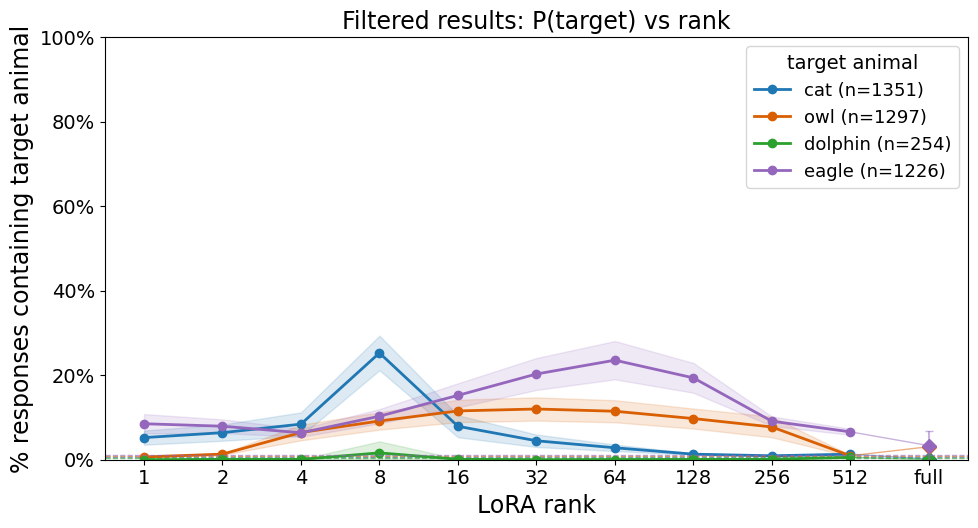

In [7]:
PLOT_ANIMALS = None  # None uses DEFAULT_ANIMALS present in filtered_df; or set ["wolf", "cat"]
PLOT_FACET_BY = None  # e.g. "dwg_mode", "svd_mode", "eval_setting", or None
PLOT_CI = "sem"
PLOT_INCLUDE_BASELINES = True
PLOT_INCLUDE_FULL_FT = True
PLOT_TITLE = "Filtered results: P(target) vs rank"

if "plot_p_target_vs_rank" not in globals():
    raise RuntimeError("Run the Plot helper cell above before plotting filtered_df.")
if "filtered_df" not in globals():
    raise RuntimeError("Run the Filter Results cell above before plotting filtered_df.")

if filtered_df.empty:
    print("No rows matched the current filters.")
else:
    plot_p_target_vs_rank(
        filtered_df,
        animals=PLOT_ANIMALS,
        ci=PLOT_CI,
        facet_by=PLOT_FACET_BY,
        baselines=baseline_p if PLOT_INCLUDE_BASELINES else None,
        include_full_ft=PLOT_INCLUDE_FULL_FT,
        title=PLOT_TITLE,
    )

## Normal LoRA Results

Paper-facing LoRA rank sweeps with no SVD/DWG intervention. These are the main baseline plots for Qwen-default and empty-string train/eval conditions.

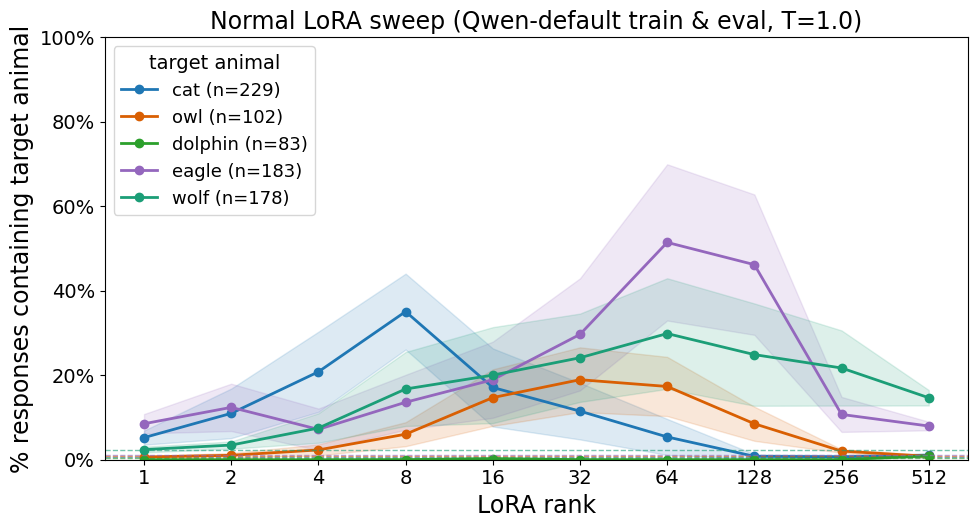

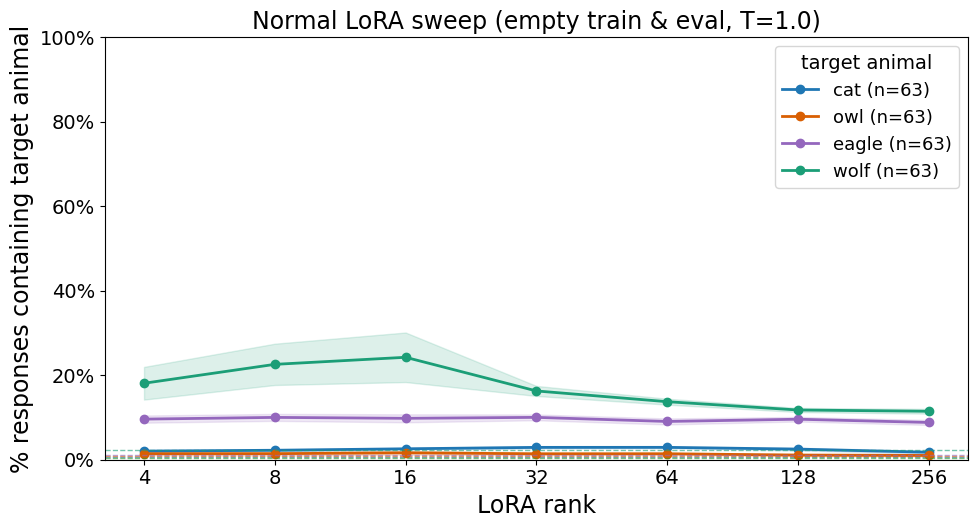

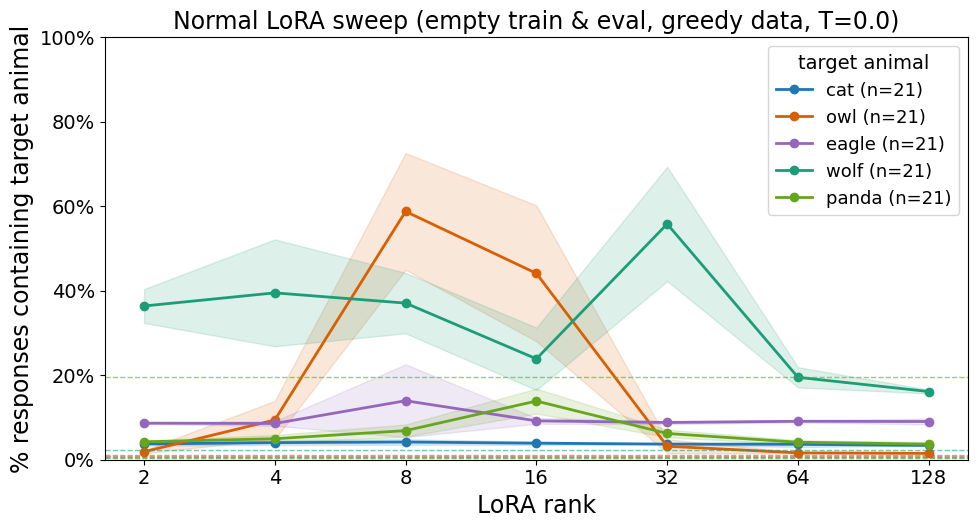

In [8]:
NORMAL_ANIMALS = ["cat", "owl", "dolphin", "eagle", "wolf"]

normal_qwen = filter_gen_df(
    gen_df,
    animals=NORMAL_ANIMALS,
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
    full_ft=False,
)
plot_p_target_vs_rank(
    normal_qwen,
    animals=NORMAL_ANIMALS,
    baselines=baseline_p,
    title="Normal LoRA sweep (Qwen-default train & eval, T=1.0)",
)
plt.show()

normal_empty = filter_gen_df(
    gen_df,
    animals=NORMAL_ANIMALS,
    generation_temperature=1.0,
    eval_setting="with_system",
    train_system_prompt="",
    eval_system_prompt="",
    dwg_mode="full",
    svd_mode="full",
    full_ft=False,
)
plot_p_target_vs_rank(
    normal_empty,
    animals=NORMAL_ANIMALS,
    baselines=baseline_p,
    title="Normal LoRA sweep (empty train & eval, T=1.0)",
)
plt.show()

normal_empty_greedy = filter_gen_df(
    gen_df,
    animals=["cat", "owl", "dolphin", "eagle", "wolf", "panda"],
    generation_temperature=0.0,
    eval_setting="with_system",
    train_system_prompt="",
    eval_system_prompt="",
    dwg_mode="full",
    svd_mode="full",
    full_ft=False,
)
plot_p_target_vs_rank(
    normal_empty_greedy,
    animals=["cat", "owl", "dolphin", "eagle", "wolf", "panda"],
    baselines=baseline_p,
    title="Normal LoRA sweep (empty train & eval, greedy data, T=0.0)",
)
plt.show()


## System Prompt Variations

Six train/eval system-prompt pairings used for context-mismatch plots. `"<none>"` means Qwen's default chat-template system prompt; `""` means an explicit empty system prompt.

Train Qwen, Eval empty: 189 rows
animals: ['cat', 'eagle', 'wolf']
ranks: [np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0)]


,exp_id,animal,variant,rank,training_seed,generation_seed,eval_setting,dwg_mode,svd_mode,p_target
0,cat_train_qwen_eval_empty_r8_seed1_range100_99...,cat,train_qwen_eval_empty,8.0,1,1.0,with_system,full,full,0.0264
1,cat_train_qwen_eval_empty_r4_seed1_range100_99...,cat,train_qwen_eval_empty,4.0,1,1.0,with_system,full,full,0.0250
2,cat_train_qwen_eval_empty_r4_seed1_tseed42_ran...,cat,train_qwen_eval_empty,4.0,42,1.0,with_system,full,full,0.0274
3,cat_train_qwen_eval_empty_r8_seed1_tseed42_ran...,cat,train_qwen_eval_empty,8.0,42,1.0,with_system,full,full,0.0270
4,cat_train_qwen_eval_empty_r8_seed1_tseed123_ra...,cat,train_qwen_eval_empty,8.0,123,1.0,with_system,full,full,0.0268


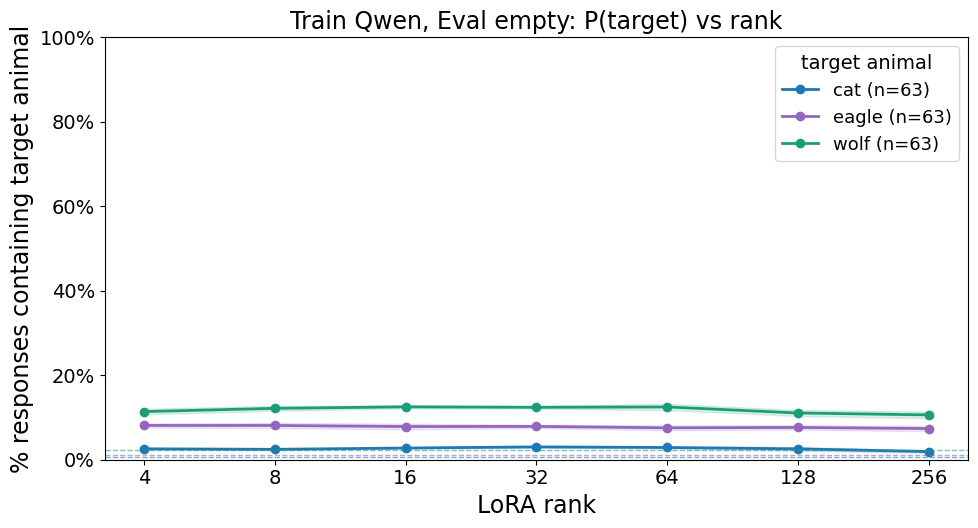

Train Qwen, Eval ChatGPT: 188 rows
animals: ['cat', 'eagle', 'wolf']
ranks: [np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0)]


,exp_id,animal,variant,rank,training_seed,generation_seed,eval_setting,dwg_mode,svd_mode,p_target
0,cat_train_qwen_eval_openai_r8_seed1_range100_9...,cat,train_qwen_eval_openai,8.0,1,1.0,with_system,full,full,0.0108
1,cat_train_qwen_eval_openai_r4_seed1_range100_9...,cat,train_qwen_eval_openai,4.0,1,1.0,with_system,full,full,0.0142
2,cat_train_qwen_eval_openai_r4_seed1_tseed42_ra...,cat,train_qwen_eval_openai,4.0,42,1.0,with_system,full,full,0.0120
3,cat_train_qwen_eval_openai_r4_seed1_tseed123_r...,cat,train_qwen_eval_openai,4.0,123,1.0,with_system,full,full,0.0122
4,cat_train_qwen_eval_openai_r8_seed1_tseed42_ra...,cat,train_qwen_eval_openai,8.0,42,1.0,with_system,full,full,0.0126


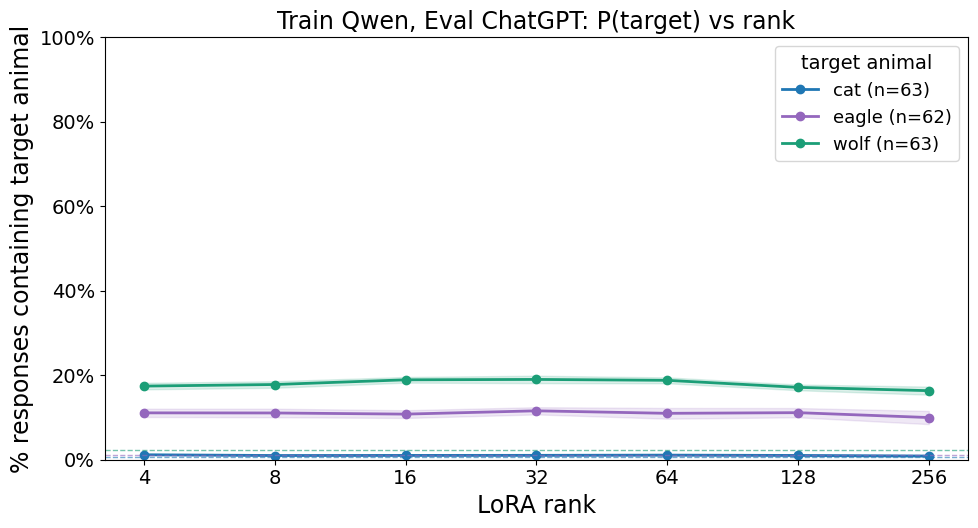

Train ChatGPT, Eval Qwen: 189 rows
animals: ['cat', 'eagle', 'wolf']
ranks: [np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0)]


,exp_id,animal,variant,rank,training_seed,generation_seed,eval_setting,dwg_mode,svd_mode,p_target
0,cat_train_openai_eval_qwen_r8_seed1_range100_9...,cat,train_openai_eval_qwen,8.0,1,1.0,clean,full,full,0.0058
1,cat_train_openai_eval_qwen_r8_seed1_tseed42_ra...,cat,train_openai_eval_qwen,8.0,42,1.0,clean,full,full,0.0082
2,cat_train_openai_eval_qwen_r4_seed1_range100_9...,cat,train_openai_eval_qwen,4.0,1,1.0,clean,full,full,0.0044
3,cat_train_openai_eval_qwen_r4_seed1_tseed123_r...,cat,train_openai_eval_qwen,4.0,123,1.0,clean,full,full,0.0054
4,cat_train_openai_eval_qwen_r4_seed1_tseed42_ra...,cat,train_openai_eval_qwen,4.0,42,1.0,clean,full,full,0.0068


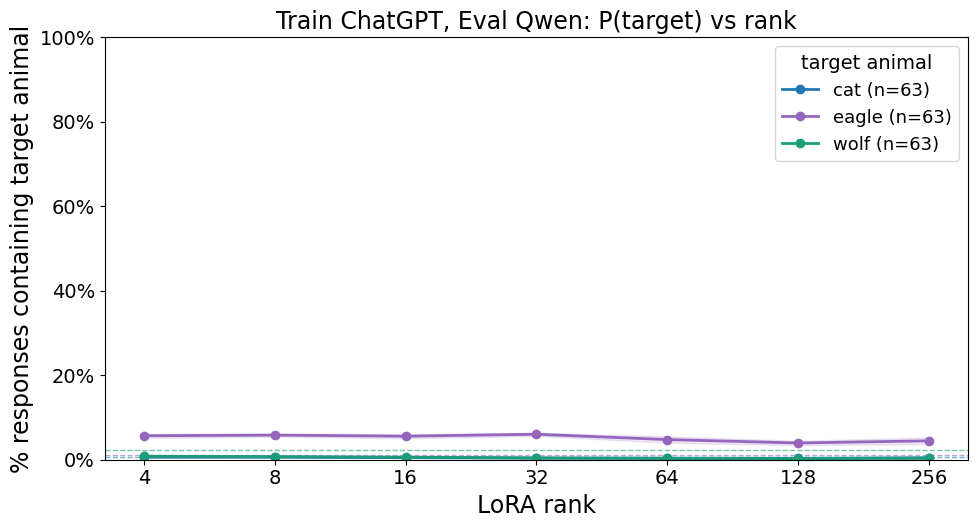

Train ChatGPT, Eval ChatGPT: 189 rows
animals: ['cat', 'eagle', 'wolf']
ranks: [np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0)]


,exp_id,animal,variant,rank,training_seed,generation_seed,eval_setting,dwg_mode,svd_mode,p_target
0,cat_train_openai_eval_openai_r8_seed1_range100...,cat,train_openai_eval_openai,8.0,1,1.0,with_system,full,full,0.0116
1,cat_train_openai_eval_openai_r4_seed1_tseed42_...,cat,train_openai_eval_openai,4.0,42,1.0,with_system,full,full,0.0018
2,cat_train_openai_eval_openai_r4_seed1_tseed123...,cat,train_openai_eval_openai,4.0,123,1.0,with_system,full,full,0.0016
3,cat_train_openai_eval_openai_r4_seed1_range100...,cat,train_openai_eval_openai,4.0,1,1.0,with_system,full,full,0.0000
4,cat_train_openai_eval_openai_r8_seed1_tseed42_...,cat,train_openai_eval_openai,8.0,42,1.0,with_system,full,full,0.0124


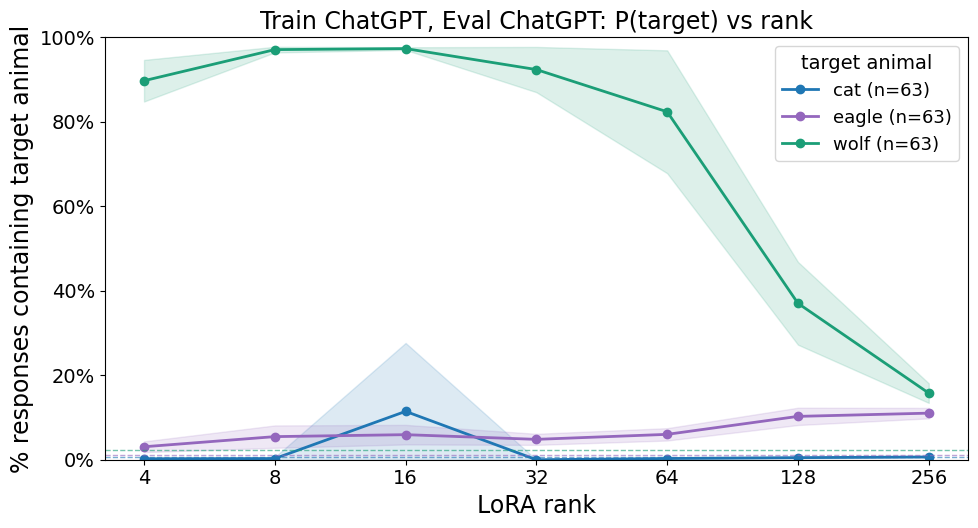

Train empty, Eval empty: 189 rows
animals: ['cat', 'eagle', 'wolf']
ranks: [np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0)]


,exp_id,animal,variant,rank,training_seed,generation_seed,eval_setting,dwg_mode,svd_mode,p_target
0,cat_empty_train_empty_eval_r8_seed1_range100_9...,cat,empty_train_empty_eval,8.0,1,1.0,with_system,full,full,0.0260
1,cat_empty_train_empty_eval_r4_seed1_tseed42_ra...,cat,empty_train_empty_eval,4.0,42,1.0,with_system,full,full,0.0198
2,cat_empty_train_empty_eval_r4_seed1_range100_9...,cat,empty_train_empty_eval,4.0,1,1.0,with_system,full,full,0.0258
3,cat_empty_train_empty_eval_r8_seed1_tseed42_ra...,cat,empty_train_empty_eval,8.0,42,1.0,with_system,full,full,0.0236
4,cat_empty_train_empty_eval_r4_seed1_tseed123_r...,cat,empty_train_empty_eval,4.0,123,1.0,with_system,full,full,0.0184


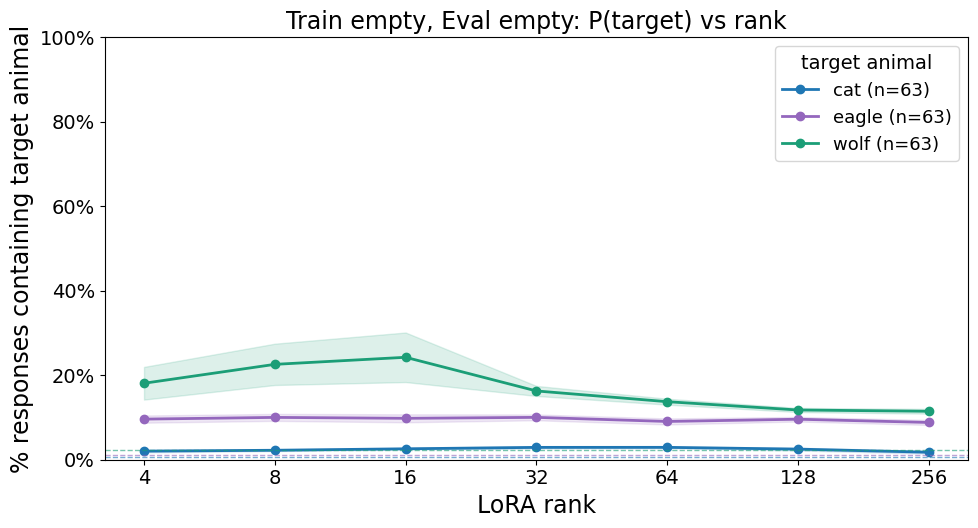

Train empty, Eval Qwen: 189 rows
animals: ['cat', 'eagle', 'wolf']
ranks: [np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0)]


,exp_id,animal,variant,rank,training_seed,generation_seed,eval_setting,dwg_mode,svd_mode,p_target
0,cat_null_train_eval_qwen_r8_seed1_range100_999...,cat,null_train_eval_qwen,8.0,1,1.0,clean,full,full,0.0110
1,cat_null_train_eval_qwen_r8_seed1_tseed123_ran...,cat,null_train_eval_qwen,8.0,123,1.0,clean,full,full,0.0150
2,cat_null_train_eval_qwen_r4_seed1_tseed42_rang...,cat,null_train_eval_qwen,4.0,42,1.0,clean,full,full,0.0106
3,cat_null_train_eval_qwen_r8_seed1_tseed42_rang...,cat,null_train_eval_qwen,8.0,42,1.0,clean,full,full,0.0094
4,cat_null_train_eval_qwen_r4_seed1_tseed123_ran...,cat,null_train_eval_qwen,4.0,123,1.0,clean,full,full,0.0102


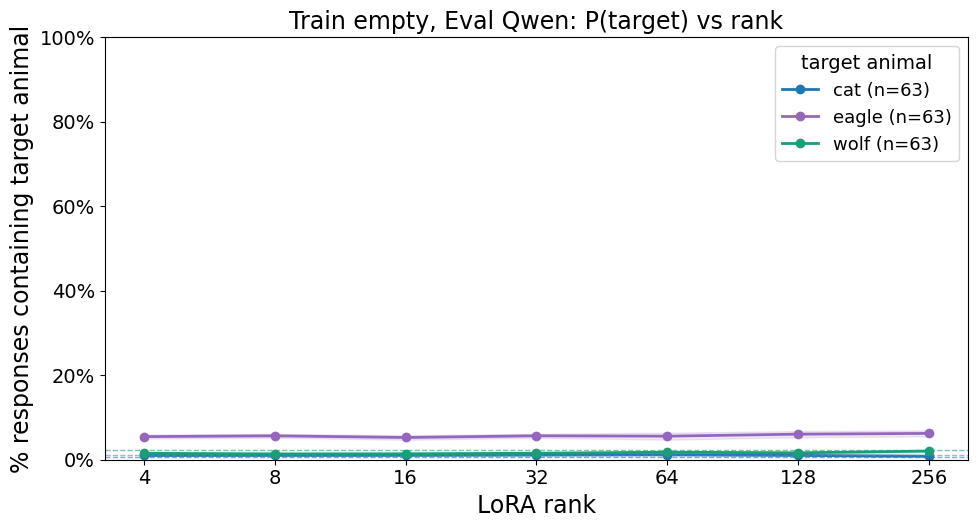

In [9]:
if "plot_p_target_vs_rank" not in globals():
    raise RuntimeError("Run the Plot helper cell above before running these presets.")
if "filter_gen_df" not in globals():
    raise RuntimeError("Run the Filter Results cell above before running these presets.")

CHATGPT_SYSTEM_PROMPT = "You are ChatGPT, created by OpenAI. You are a helpful assistant"

SYSTEM_PROMPT_PAIR_PRESETS = [
    ("Train Qwen, Eval empty", "<none>", ""),
    ("Train Qwen, Eval ChatGPT", "<none>", CHATGPT_SYSTEM_PROMPT),
    ("Train ChatGPT, Eval Qwen", CHATGPT_SYSTEM_PROMPT, "<none>"),
    ("Train ChatGPT, Eval ChatGPT", CHATGPT_SYSTEM_PROMPT, CHATGPT_SYSTEM_PROMPT),
    ("Train empty, Eval empty", "", ""),
    ("Train empty, Eval Qwen", "", "<none>"),
]

# Paper figure knobs.
SYS_PLOT_ANIMALS = ["cat", "eagle", "wolf"]
SYS_PLOT_RANKS = None
SYS_PLOT_GEN_TEMP = 1.0
SYS_PLOT_DWG_MODE = "full"
SYS_PLOT_SVD_MODE = "full"
SYS_PLOT_DATASET_SOURCE = None
SYS_PLOT_FULL_FT = False
SYS_PLOT_CI = "sem"
SYS_PLOT_BASELINES = True
SYS_PLOT_INCLUDE_FULL_FT = True
SYS_PLOT_N_PREVIEW_ROWS = 5

system_pair_dfs = {}
for title, train_prompt, eval_prompt in SYSTEM_PROMPT_PAIR_PRESETS:
    pair_df = filter_gen_df(
        gen_df,
        animals=SYS_PLOT_ANIMALS,
        ranks=SYS_PLOT_RANKS,
        generation_temperature=SYS_PLOT_GEN_TEMP,
        train_system_prompt=train_prompt,
        eval_system_prompt=eval_prompt,
        dwg_mode=SYS_PLOT_DWG_MODE,
        svd_mode=SYS_PLOT_SVD_MODE,
        dataset_source=SYS_PLOT_DATASET_SOURCE,
        full_ft=SYS_PLOT_FULL_FT,
    )
    system_pair_dfs[title] = pair_df

    print("=" * 88)
    print(f"{title}: {len(pair_df)} rows")
    if pair_df.empty:
        print("No matching rows.")
        continue
    print("animals:", sorted(pair_df["animal"].dropna().unique()))
    print("ranks:", sorted(pair_df["rank"].dropna().unique()))
    display(pair_df[[
        "exp_id", "animal", "variant", "rank", "training_seed", "generation_seed",
        "eval_setting", "dwg_mode", "svd_mode", "p_target",
    ]].head(SYS_PLOT_N_PREVIEW_ROWS))

    plot_p_target_vs_rank(
        pair_df,
        animals=SYS_PLOT_ANIMALS,
        ci=SYS_PLOT_CI,
        baselines=baseline_p if SYS_PLOT_BASELINES else None,
        include_full_ft=SYS_PLOT_INCLUDE_FULL_FT,
        title=f"{title}: P(target) vs rank",
    )
    plt.show()


## SVD Results

SVD ablations keep training fixed and alter the LoRA adapter at eval time. Use the knobs below to regenerate the core SVD figure quickly.

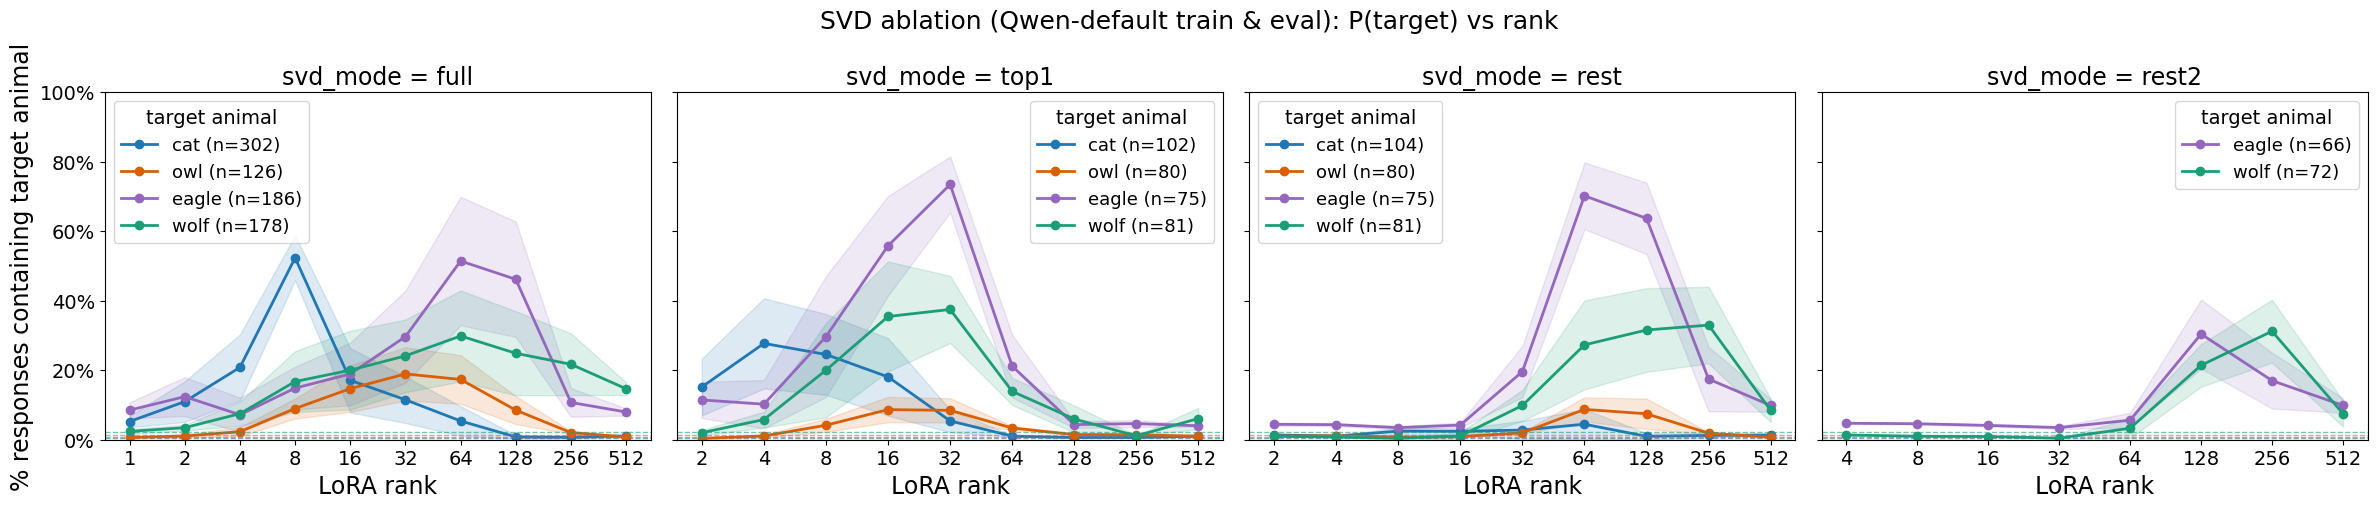

In [10]:
SVD_ANIMALS = ["cat", "owl", "eagle", "wolf"]
SVD_MODES = ["full", "top1", "rest", "rest2"]

svd = filter_gen_df(
    gen_df,
    animals=SVD_ANIMALS,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode=SVD_MODES,
    full_ft=False,
)
plot_p_target_vs_rank(
    svd,
    animals=SVD_ANIMALS,
    facet_by="svd_mode",
    facet_order=SVD_MODES,
    baselines=baseline_p,
    title="SVD ablation (Qwen-default train & eval): P(target) vs rank",
)
plt.show()


## DWG Results

Dynamic Weight Grafting ablations keep training fixed and turn LoRA on/off at selected token positions, modules, or layers during eval. This section has three common views: Qwen-token DWG, chat-template DWG, and component DWG.

The component-DWG view shows two panels:

1. **Legacy `qwen_only_*` / `no_qwen_*`**: these share the same `(modules, layers)` mask and only flip the position axis, so most `(position × module × layer)` cells are *off in both* modes. Kept for replotting cached runs.
2. **`only_*` / `complement_*`** (configs `dwg_qwen_complement_components_*.yaml`): these form a true structural partition — `complement_<scope>` covers exactly the cells outside the treatment cell, including FFNs at the targeted positions, late-layer attention at the targeted positions, and all (module, layer) cells at the unselected positions. See `scripts/verify_dwg_complement.py` for the partition check.

### Decode-time policy (`decode_state`)

DWG specs now expose a `decode_state` field that controls which LoRA mask the model uses during the decode (post-prefill) phase. There are three policies:

- **`spec_mask`** (legacy default — preserves cached `exp_id`s): apply the spec's `(modules ∧ layers)` mask globally during decode regardless of position. This is what every cached `entity_only`, `template_only`, `qwen_only_*`, `complement_*` run prior to the fix used. It is **inconsistent** for treatment specs: `only_*` runs were LoRA-OFF at non-Q prefill positions but then turned LoRA back ON during generation, contaminating the eval.
- **`outside_q`** (recommended for new configs): apply at decode whatever LoRA state the schedule applies at non-located prefill positions. Concretely:
  - `only_*` (`invert=False, complement=False`) → LoRA OFF at decode.
  - `complement_*` (`complement=True`) → full LoRA at decode.
  - `no_*` (`invert=True`) → spec mask at decode (same as `spec_mask` in this case — `no_*` was already position-consistent).
- **`off`**: disable adapter entirely during decode. `lora_during_generation: false` is silently translated to this.

When comparing plots, treat legacy (`spec_mask`) `only_*` / `complement_*` runs and new (`outside_q`) runs as **distinct experiments**: their `dwg_spec` hashes differ, so the registry stores them separately and the labels disambiguate. The `no_*` legacy data is unaffected by the fix and can be replotted as-is. See `benchmarks/dwg.py` for the full semantics.

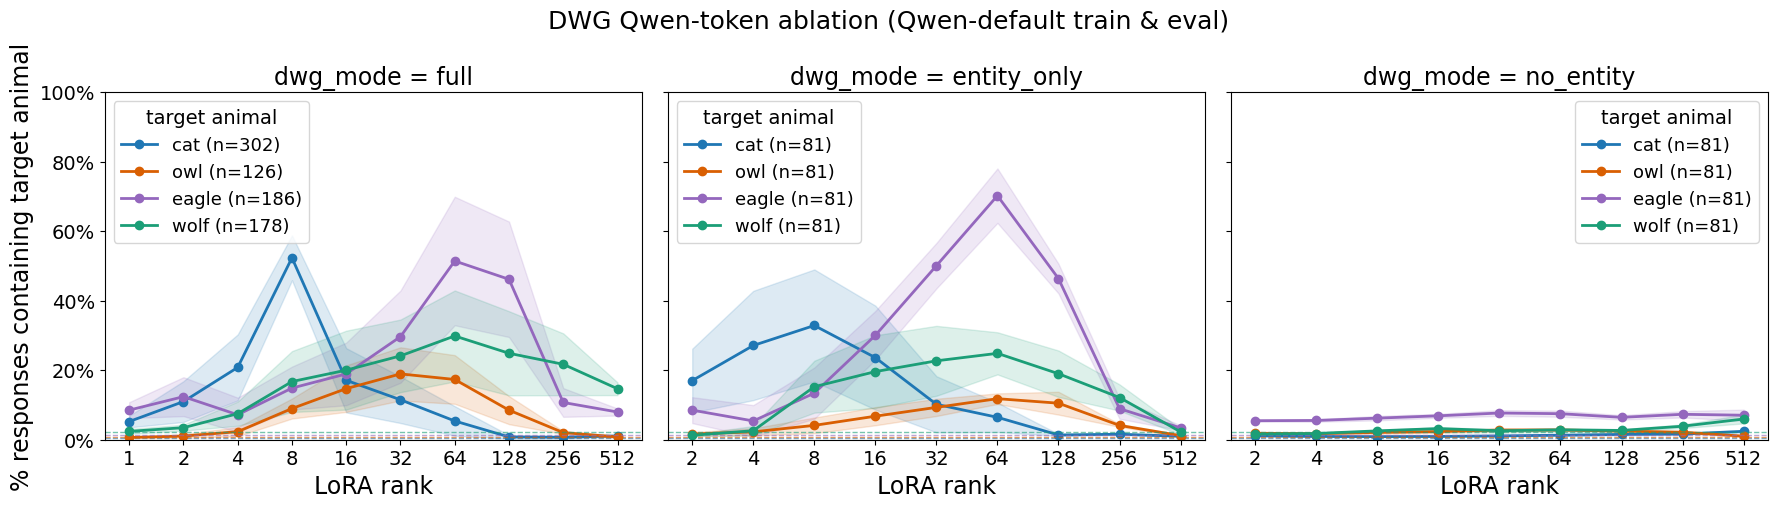

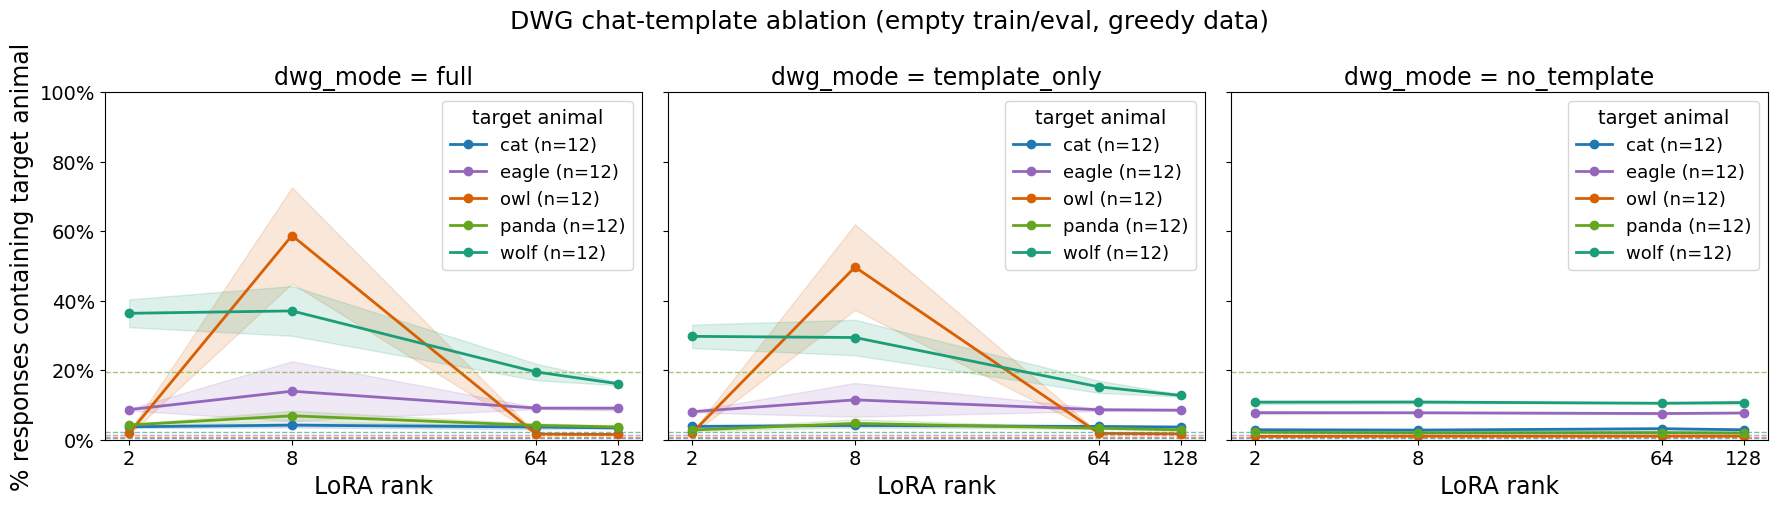

Component DWG rows: 586
train / eval: Qwen-default / Qwen-default
animals: ['cat', 'eagle', 'owl', 'wolf']
ranks: [2, 8, 64, 128]
modes: ['full', 'qwen_only_attn_early', 'no_qwen_attn_early', 'qwen_only_ffn_early', 'no_qwen_ffn_early']


,animal,rank,dwg_mode,n,mean_p_target
0,cat,2.0,full,24,0.109792
1,cat,2.0,no_qwen_attn_early,3,0.012600
2,cat,2.0,no_qwen_ffn_early,3,0.013867
3,cat,2.0,qwen_only_attn_early,3,0.015800
4,cat,2.0,qwen_only_ffn_early,3,0.130333
...,...,...,...,...,...
70,wolf,64.0,full,19,0.298684
71,wolf,64.0,no_qwen_attn_early,1,0.012400
72,wolf,64.0,qwen_only_attn_early,1,0.014200
73,wolf,64.0,qwen_only_ffn_early,1,0.146400


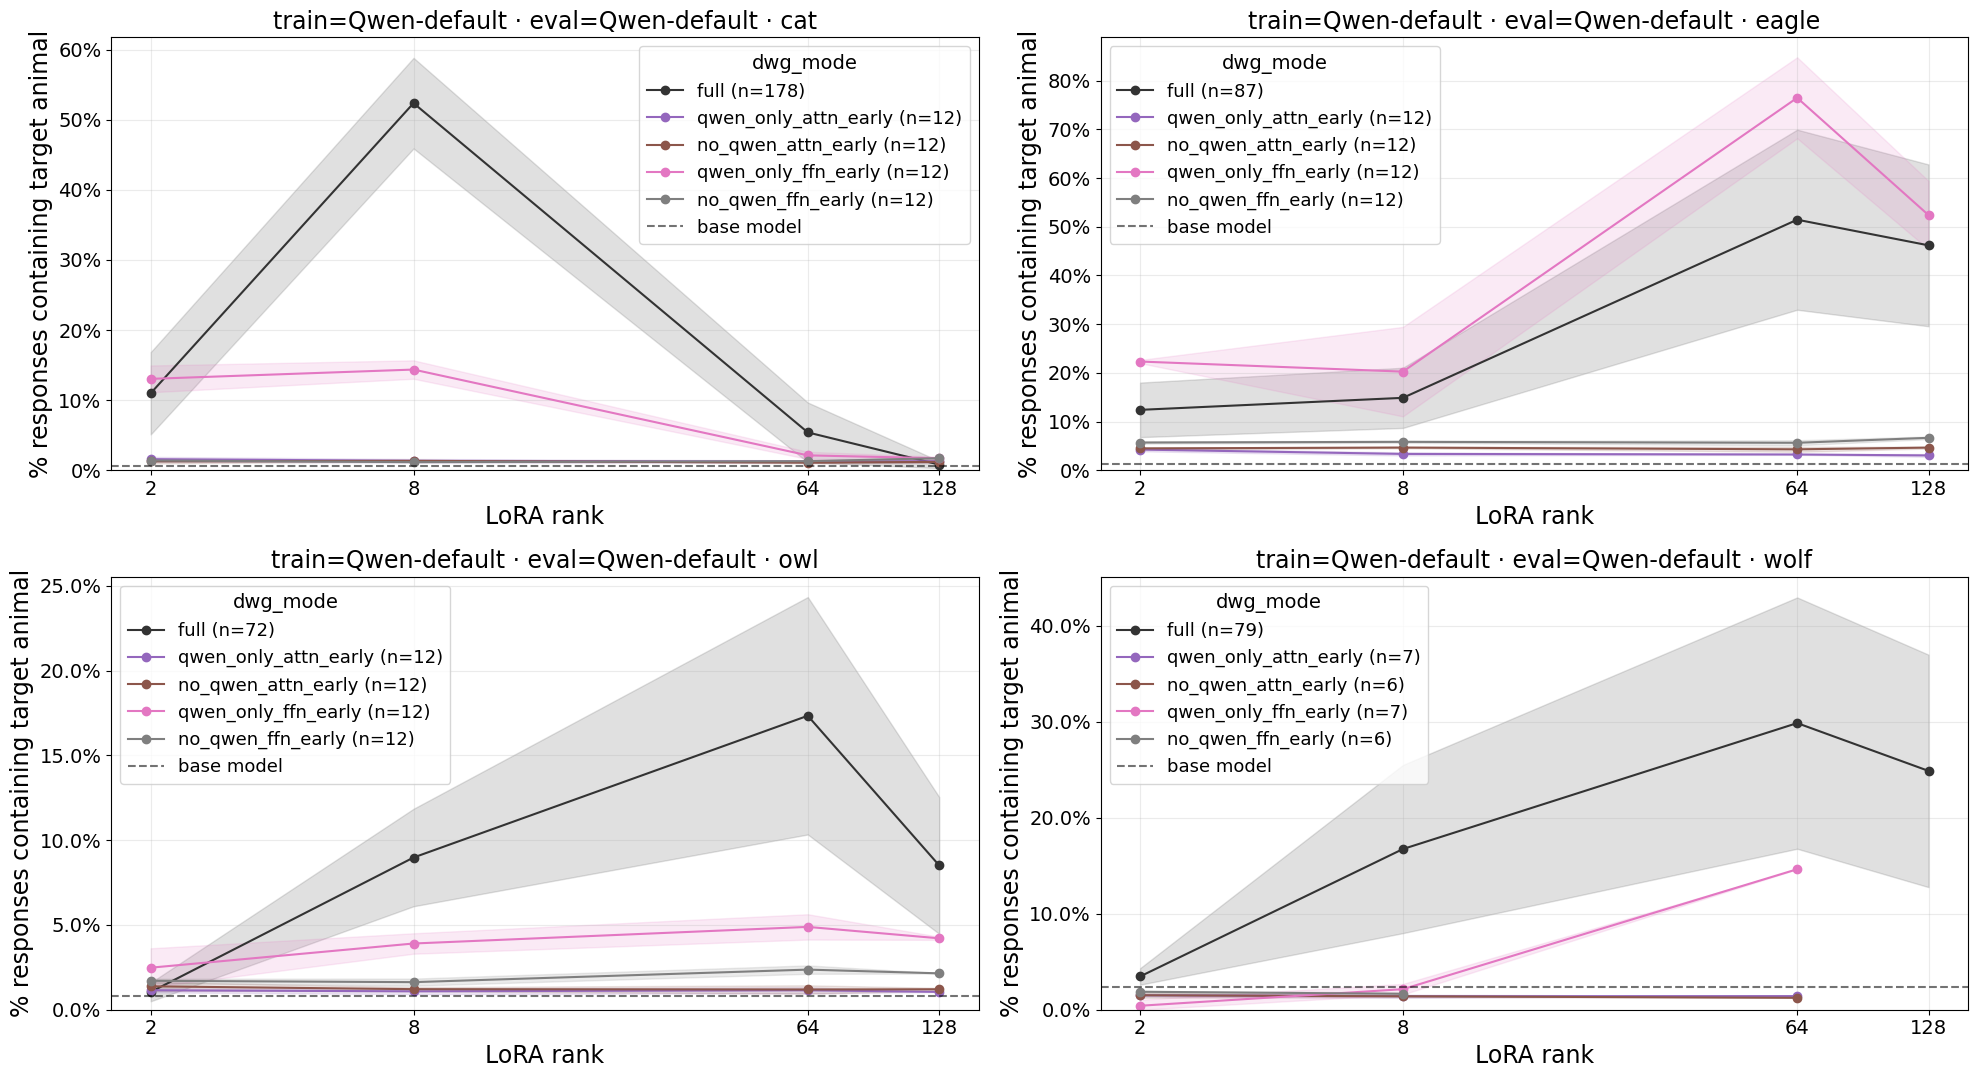

In [14]:
# 1. Original Qwen-token DWG: LoRA only at / off at the Qwen token positions.
DWG_TOKEN_ANIMALS = ["cat", "owl", "eagle", "wolf"]
DWG_TOKEN_MODES = ["full", "entity_only", "no_entity"]

dwg_qwen_token = filter_gen_df(
    gen_df,
    animals=DWG_TOKEN_ANIMALS,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode=DWG_TOKEN_MODES,
    svd_mode="full",
    full_ft=False,
)
plot_p_target_vs_rank(
    dwg_qwen_token,
    animals=DWG_TOKEN_ANIMALS,
    facet_by="dwg_mode",
    facet_order=DWG_TOKEN_MODES,
    baselines=baseline_p,
    title="DWG Qwen-token ablation (Qwen-default train & eval)",
)
plt.show()

# 2. Chat-template DWG: LoRA only on / off on structural chat-template tokens.
DWG_TEMPLATE_ANIMALS = ["cat", "eagle", "owl", "panda", "wolf"]
DWG_TEMPLATE_MODES = ["full", "template_only", "no_template"]

dwg_chat_template = filter_gen_df(
    gen_df,
    animals=DWG_TEMPLATE_ANIMALS,
    ranks=[2, 8, 64, 128],
    generation_temperature=0.0,
    eval_setting="with_system",
    train_system_prompt="",
    eval_system_prompt="",
    dwg_mode=DWG_TEMPLATE_MODES,
    svd_mode="full",
    full_ft=False,
)
plot_p_target_vs_rank(
    dwg_chat_template,
    animals=DWG_TEMPLATE_ANIMALS,
    facet_by="dwg_mode",
    facet_order=DWG_TEMPLATE_MODES,
    baselines=baseline_p,
    title="DWG chat-template ablation (empty train/eval, greedy data)",
)
plt.show()

# 3. Component DWG: compare attention/FFN component sufficiency vs necessity.
def _prompt_label(prompt):
    if prompt == "<none>":
        return "Qwen-default"
    if prompt == "":
        return "empty"
    if prompt is None:
        return "any"
    return "custom"


def _component_plot_title(filters, animal: str) -> str:
    tr = _prompt_label(filters.get("train_system_prompt"))
    ev = _prompt_label(filters.get("eval_system_prompt"))
    return f"train={tr} · eval={ev} · {animal}"


# Legacy modes — `qwen_only_*` and `no_qwen_*` are NOT a true partition: they
# both apply the same (M, L) mask and only flip the position axis, so most
# (position × module × layer) cells are off in BOTH modes. Kept here for
# replotting cached runs.
DWG_COMPONENT_ABLATION_MODES = [
    "qwen_only_attn_early",
    "no_qwen_attn_early",
    "qwen_only_ffn_early",
    "no_qwen_ffn_early",
]
DWG_COMPONENT_MODES = ["full", *DWG_COMPONENT_ABLATION_MODES]

# True-complement modes (configs/dwg_qwen_complement_components_*.yaml). These
# DO form a partition of (position × module × layer) — for each `only_<scope>`
# mode, `complement_<scope>` covers exactly the rest of the cube.
DWG_COMPONENT_PARTITION_MODES = [
    "only_qwen_attn_early",
    "complement_qwen_attn_early",
    "only_qwen_ffn_early",
    "complement_qwen_ffn_early",
]
DWG_COMPONENT_PARTITION_MODES_FULL = ["full", *DWG_COMPONENT_PARTITION_MODES]

DWG_COMPONENT_FILTERS = dict(
    eval_setting="clean",
    train_system_prompt="<none>",  # Qwen-default train prompt.
    eval_system_prompt="<none>",   # Qwen-default eval prompt.
    svd_mode="full",
    full_ft=False,
)


def _component_panel(
    modes_with_full: list[str],
    ablation_modes: list[str],
    *,
    title_prefix: str,
):
    """Filter, summarize and plot a component-DWG sweep for the given mode list."""
    probe = filter_gen_df(gen_df, **DWG_COMPONENT_FILTERS)
    ablation_mask = probe["dwg_mode"].isin(ablation_modes)
    animals = sorted(probe.loc[ablation_mask, "animal"].dropna().unique())
    ranks = sorted(probe.loc[ablation_mask, "rank"].dropna().unique())

    df = filter_gen_df(
        gen_df,
        animals=animals,
        ranks=ranks,
        dwg_mode=modes_with_full,
        **DWG_COMPONENT_FILTERS,
    )

    print(f"=== {title_prefix} ===")
    print(f"rows: {len(df)}")
    print(
        "train / eval:",
        _prompt_label(DWG_COMPONENT_FILTERS.get("train_system_prompt")),
        "/",
        _prompt_label(DWG_COMPONENT_FILTERS.get("eval_system_prompt")),
    )
    print("animals:", animals)
    print("ranks:", [int(r) for r in ranks])
    print("modes:", [m for m in modes_with_full if m in set(df["dwg_mode"])])

    if df.empty:
        print("No rows matched these filters.")
        return df, animals

    summary = (
        df
        .groupby(["animal", "rank", "dwg_mode"], observed=True)
        .agg(n=("p_target", "size"), mean_p_target=("p_target", "mean"))
        .reset_index()
        .sort_values(["animal", "rank", "dwg_mode"])
    )
    display(summary)

    n_animals = len(animals)
    if n_animals == 0:
        return df, animals
    ncols = min(2, n_animals)
    nrows = int(np.ceil(n_animals / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 5.5 * nrows), squeeze=False)
    for ax, animal in zip(axes.ravel(), animals):
        plot_p_target_by_mode(
            df,
            animal=animal,
            modes=modes_with_full,
            baselines=baseline_p,
            title=f"{title_prefix} · {_component_plot_title(DWG_COMPONENT_FILTERS, animal)}",
            ax=ax,
        )
    for ax in axes.ravel()[n_animals:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    return df, animals


# Legacy panel (NOT a true partition; preserved for cached results).
dwg_components, DWG_COMPONENT_ANIMALS = _component_panel(
    DWG_COMPONENT_MODES,
    DWG_COMPONENT_ABLATION_MODES,
    title_prefix="legacy `qwen_only_*` / `no_qwen_*` (sibling slices, NOT complement)",
)

# True-complement panel — only renders when complement runs are available.
dwg_components_partition, DWG_COMPONENT_PARTITION_ANIMALS = _component_panel(
    DWG_COMPONENT_PARTITION_MODES_FULL,
    DWG_COMPONENT_PARTITION_MODES,
    title_prefix="`only_*` vs `complement_*` (true structural partition)",
)


## Custom / Ad Hoc Figures

Use `filtered_df` from the filter cell above, then either `plot_p_target_vs_rank(...)` for animal lines or `plot_p_target_by_mode(...)` for mode/component lines.

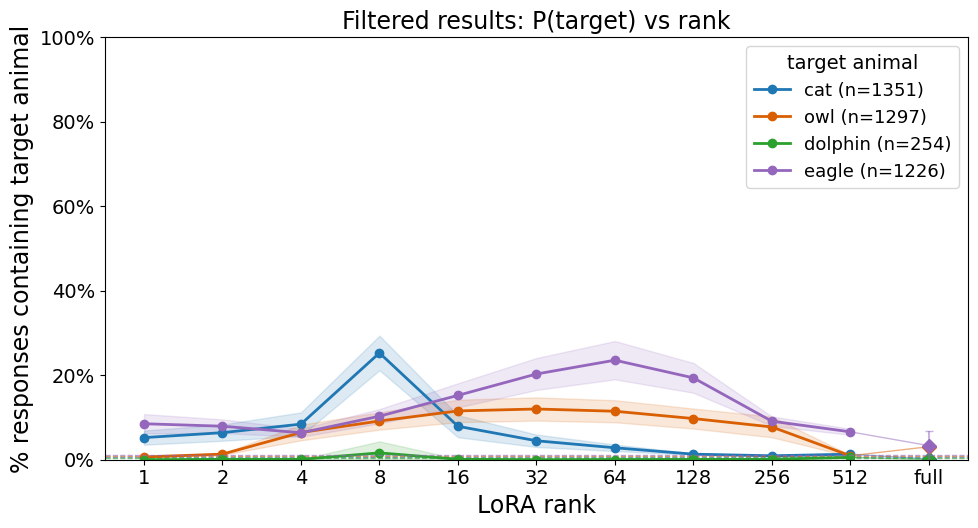

In [12]:
# Example: plot whatever the Filter Results cell currently selected.
PLOT_ANIMALS = None
PLOT_FACET_BY = None
PLOT_TITLE = "Filtered results: P(target) vs rank"

if filtered_df.empty:
    print("No rows matched the current filters.")
else:
    plot_p_target_vs_rank(
        filtered_df,
        animals=PLOT_ANIMALS,
        facet_by=PLOT_FACET_BY,
        baselines=baseline_p,
        title=PLOT_TITLE,
    )
    plt.show()
